In [1]:
import tensorflow as tf

In [3]:
import kagglehub
kagglehub.login()
path = kagglehub.competition_download('data-science-bowl-2018')
print("Path to competition files:", path)

100%|██████████| 358M/358M [00:01<00:00, 190MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/data-science-bowl-2018
Kaggle credentials set.
Kaggle credentials successfully validated.


In [4]:
import os
TRAIN = os.path.join(path, 'stage1_train')
TEST  = os.path.join(path, 'stage1_test')

In [5]:
def encoder_block(inputs, num_filters):
    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same', activation='relu')(inputs)
    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same', activation='relu')(x)
    p = tf.keras.layers.MaxPool2D((2, 2))(x)
    return x, p

def decoder_block(inputs, skip, num_filters):
    x = tf.keras.layers.Conv2DTranspose(num_filters, 2, strides=2, padding='same')(inputs)
    x = tf.keras.layers.Concatenate()([x, skip])
    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(num_filters, 3, padding='same', activation='relu')(x)
    return x

def unet_model(input_shape=(256, 256, 3), num_classes=1):
    inputs = tf.keras.layers.Input(input_shape)
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='same', activation='relu')(p4)
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='same', activation='relu')(b1)
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)
    outputs = tf.keras.layers.Conv2D(num_classes, 1, activation='sigmoid')(d4)
    return tf.keras.models. Model(inputs, outputs, name='U-Net')


In [6]:
import zipfile, os

# Extract the training zip into a folder
with zipfile.ZipFile(os.path.join(path, 'stage1_train.zip'), 'r') as z:
    z.extractall(os.path.join(path, 'stage1_train'))

TRAIN = os.path.join(path, 'stage1_train')
ids = os.listdir(TRAIN)
print(len(ids), 'training samples')

670 training samples


In [7]:
import numpy as np
from skimage.io import imread
from skimage.transform import resize
from tqdm import tqdm

IMG   = 256
TRAIN = os.path.join(path, 'stage1_train')
ids   = os.listdir(TRAIN)

X = np.zeros((len(ids), IMG, IMG, 3), np.float32)
Y = np.zeros((len(ids), IMG, IMG, 1), np.float32)

for i, id_ in enumerate(tqdm(ids)):
    img = imread(f'{TRAIN}/{id_}/images/{id_}.png')[:, :, :3]
    X[i] = resize(img, (IMG, IMG), preserve_range=True, anti_aliasing=True) / 255.

    mask = np.zeros((IMG, IMG, 1))
    for m in os.listdir(f'{TRAIN}/{id_}/masks'):
        mm = imread(f'{TRAIN}/{id_}/masks/{m}')
        mm = resize(mm, (IMG, IMG), preserve_range=True, anti_aliasing=False)
        mask = np.maximum(mask, (mm > 0)[..., None])
    Y[i] = mask

print('X:', X.shape, ' Y:', Y.shape)


100%|██████████| 670/670 [02:01<00:00,  5.52it/s]

X: (670, 256, 256, 3)  Y: (670, 256, 256, 1)


In [11]:
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    inter = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * inter + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

model = unet_model(input_shape=(256, 256, 3), num_classes=1)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X, Y, validation_split=0.1, batch_size=16, epochs=20)

Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 46s 968ms/step - accuracy: 0.8359 - loss: 0.3987 - val_accuracy: 0.8631 - val_loss: 0.2696
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 31s 827ms/step - accuracy: 0.8855 - loss: 0.2295 - val_accuracy: 0.8619 - val_loss: 0.2526
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 34s 886ms/step - accuracy: 0.8823 - loss: 0.2227 - val_accuracy: 0.9039 - val_loss: 0.2044
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 34s 881ms/step - accuracy: 0.9382 - loss: 0.1540 - val_accuracy: 0.9518 - val_loss: 0.1229
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 33s 868ms/step - accuracy: 0.9591 - loss: 0.1072 - val_accuracy: 0.9459 - val_loss: 0.1440
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 33s 880ms/step - accuracy: 0.9606 - loss: 0.1030 - val_accuracy: 0.9602 - val_loss: 0.1026
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 33s 868ms/step - accuracy: 0.9665 - loss: 0.0865 - val_accuracy: 0.9664 - val_loss: 0.0868
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 33s 866ms/step - accuracy: 0.9677 - loss: 0.0835 - val_accu

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 844ms/step


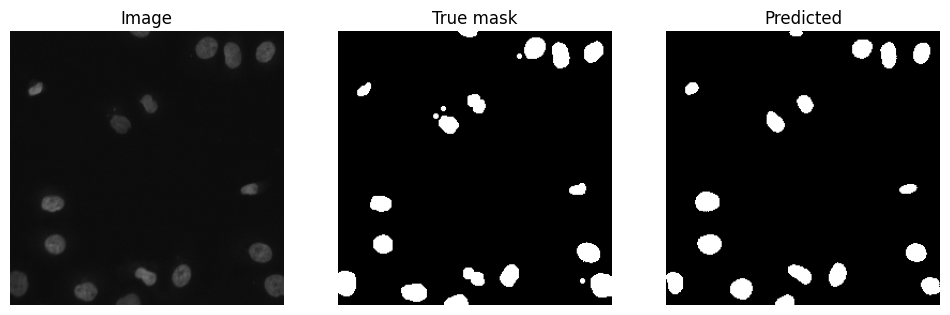

In [12]:
import matplotlib.pyplot as plt

i = 0
pred = model.predict(X[i:i+1])[0, :, :, 0]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(X[i]);                  ax[0].set_title('Image');     ax[0].axis('off')
ax[1].imshow(Y[i, :, :, 0], 'gray'); ax[1].set_title('True mask'); ax[1].axis('off')
ax[2].imshow(pred > 0.5, 'gray');    ax[2].set_title('Predicted'); ax[2].axis('off')
plt.show()
